# Stochastic Processes with Monte Carlo
## Student Notebook: Random Walk $\to$ Brownian Motion / Wiener Process $\to$ Itô Processes / Langevin Equation / SDEs $\to$ Diffusion Equation $\to$ Fokker–Planck Equation

This notebook is a **student-facing companion** to the lecture on stochastic processes in a course built around **Monte Carlo methods**.

### Main idea
We follow one coherent chain of ideas:

$$
\text{Random walk}
\;\longrightarrow\;
\text{Brownian motion / Wiener process}
\;\longrightarrow\;
\text{Itô process / Langevin equation / SDE} \\
\;\longrightarrow\;
\text{Diffusion equation}
\;\longrightarrow\;
\text{Fokker--Planck equation}
$$


In [18]:
import numpy as np
import matplotlib.pyplot as plt

# Reproducibility
rng = np.random.default_rng(42)

# A slightly cleaner default figure size for readability
plt.rcParams["figure.figsize"] = (8, 4.5)
plt.rcParams["font.size"] = 11

## 1. Why stochastic processes?

Many systems evolve partly **deterministically** and partly **randomly**:
- a pollen grain in water,
- a diffusing molecule,
- a noisy physical measurement,
- a particle in a thermal bath,
- a financial toy model,
- Monte Carlo samples in a simulation.

A natural first model is the **random walk**.

## 2. The simplest model: the 1D random walk

Let $X_n$ denote the position after $n$ steps.  
A symmetric random walk is defined by

$$
X_{n+1} = X_n + \xi_n,
\qquad \xi_n \in \{-1,+1\},
\qquad \mathbb P(\xi_n=1)=\mathbb P(\xi_n=-1)=\frac12.
$$

### Key facts
- The increments are independent.
- $\mathbb E[\xi_n]=0$.
- $\mathrm{Var}(\xi_n)=1$.
- Therefore
  $$
  \mathbb E[X_n]=0,
  \qquad
  \mathrm{Var}(X_n)=n.
  $$
- The typical distance grows like $\sqrt{n}$, not like $n$.

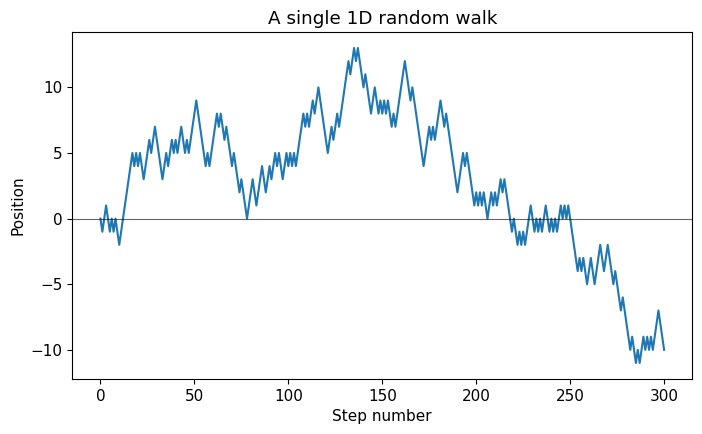

In [19]:
def random_walk_1d(n_steps, n_walkers=1, step_size=1.0, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    steps = rng.choice([-step_size, step_size], size=(n_walkers, n_steps))
    positions = np.cumsum(steps, axis=1)
    positions = np.hstack([np.zeros((n_walkers, 1)), positions])  # include X_0 = 0
    return positions

n_steps = 300
walk = random_walk_1d(n_steps, n_walkers=1, rng=rng)[0]

plt.plot(walk, lw=1.5)
plt.axhline(0, color="black", lw=0.8, alpha=0.6)
plt.xlabel("Step number")
plt.ylabel("Position")
plt.title("A single 1D random walk")
plt.show()

A single trajectory looks irregular and unpredictable.

Now compare **many independent walkers**.

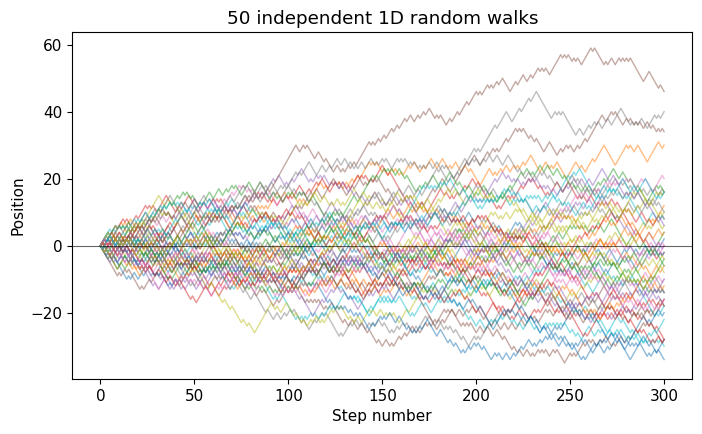

In [20]:
n_steps = 300
n_walkers = 50
walks = random_walk_1d(n_steps, n_walkers=n_walkers, rng=rng)

for i in range(n_walkers):
    plt.plot(walks[i], alpha=0.5, lw=1)

plt.axhline(0, color="black", lw=0.8, alpha=0.6)
plt.xlabel("Step number")
plt.ylabel("Position")
plt.title(f"{n_walkers} independent 1D random walks")
plt.show()

### Ensemble statistics

For a symmetric walk:
$$
\mathbb E[X_n] = 0,\qquad \mathbb E[X_n^2]=n.
$$

Let us verify this numerically.

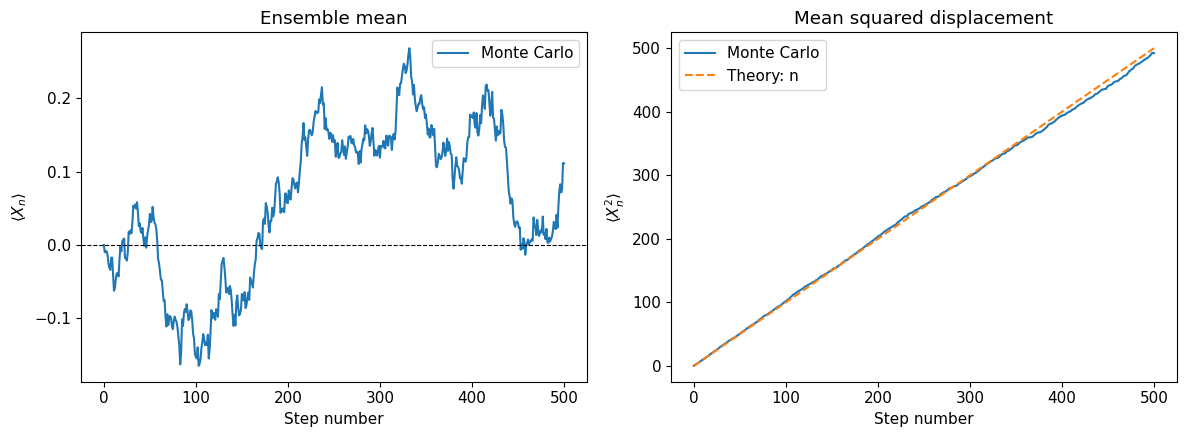

In [21]:
n_steps = 500
n_walkers = 5000
walks = random_walk_1d(n_steps, n_walkers=n_walkers, rng=rng)

mean_pos = walks.mean(axis=0)
msd = (walks**2).mean(axis=0)   # mean squared displacement

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(mean_pos, label="Monte Carlo")
ax[0].axhline(0, color="black", lw=0.8, ls="--")
ax[0].set_title("Ensemble mean")
ax[0].set_xlabel("Step number")
ax[0].set_ylabel(r"$\langle X_n \rangle$")

ax[1].plot(msd, label="Monte Carlo")
ax[1].plot(np.arange(n_steps + 1), np.arange(n_steps + 1), ls="--", label="Theory: n")
ax[1].set_title("Mean squared displacement")
ax[1].set_xlabel("Step number")
ax[1].set_ylabel(r"$\langle X_n^2 \rangle$")

for a in ax:
    a.legend()

plt.tight_layout()
plt.show()

### Histogram after a fixed number of steps

The **distribution** of positions becomes broader with time.  
For large $n$, the central limit theorem suggests an approximately Gaussian shape.

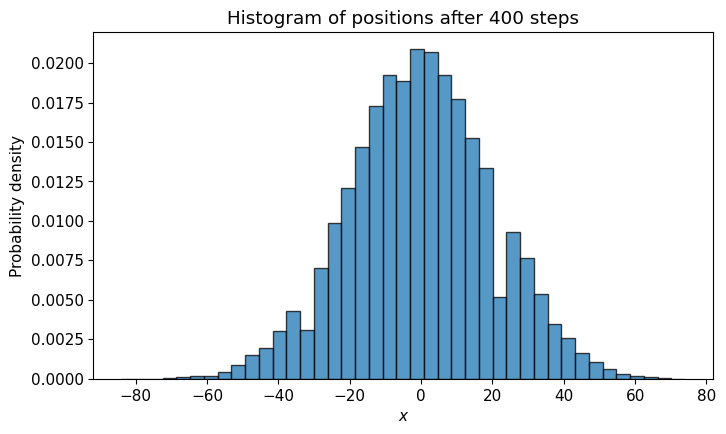

In [22]:
n_steps = 400
n_walkers = 20000
walks = random_walk_1d(n_steps, n_walkers=n_walkers, rng=rng)
final_positions = walks[:, -1]

plt.hist(final_positions, bins=41, density=True, alpha=0.75, edgecolor="black")
plt.xlabel(r"$x$")
plt.ylabel("Probability density")
plt.title(f"Histogram of positions after {n_steps} steps")
plt.show()

## 3. A 2D random walk

A 2D random walk is often more visually intuitive for students because it looks like a cloud that spreads out.

One simple version:
- at each step, choose one of the four directions
  $(\pm 1,0)$ or $(0,\pm 1)$ with equal probability.

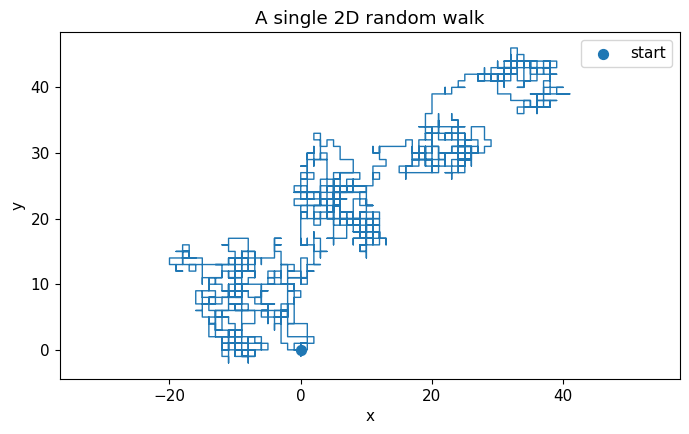

In [23]:
def random_walk_2d(n_steps, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    directions = np.array([[1,0], [-1,0], [0,1], [0,-1]])
    steps = directions[rng.integers(0, 4, size=n_steps)]
    pos = np.vstack([np.zeros((1, 2)), np.cumsum(steps, axis=0)])
    return pos

path2d = random_walk_2d(2000, rng=rng)

plt.plot(path2d[:,0], path2d[:,1], lw=1)
plt.scatter([0], [0], s=50, label="start")
plt.xlabel("x")
plt.ylabel("y")
plt.title("A single 2D random walk")
plt.axis("equal")
plt.legend()
plt.show()

This spreading cloud is a discrete precursor of **diffusion**.

---

## 4. From random walk to Brownian motion

To pass to continuous time, let the time step be $\Delta t$ and scale the random increment like

$$
\Delta X \sim \sqrt{\Delta t}.
$$

This scaling is crucial:
- deterministic motion scales like $dt$,
- noise scales like $\sqrt{dt}$.

The continuous-time limit is **Brownian motion** (or the **Wiener process**) $W_t$.

### Definition of the Wiener process
A stochastic process $W_t$ is a Wiener process if:
1. $W_0 = 0$,
2. increments are independent,
3. $W_{t+s} - W_t \sim \mathcal N(0,s)$,
4. sample paths are continuous.

### Important properties
$$
\mathbb E[W_t]=0,\qquad \mathrm{Var}(W_t)=t.
$$

In Monte Carlo langluage, we simulate Wiener increments as
$$
W_{t+\Delta t} - W_t = \sqrt{\Delta t}\, Z,
\qquad Z \sim \mathcal N(0,1).
$$

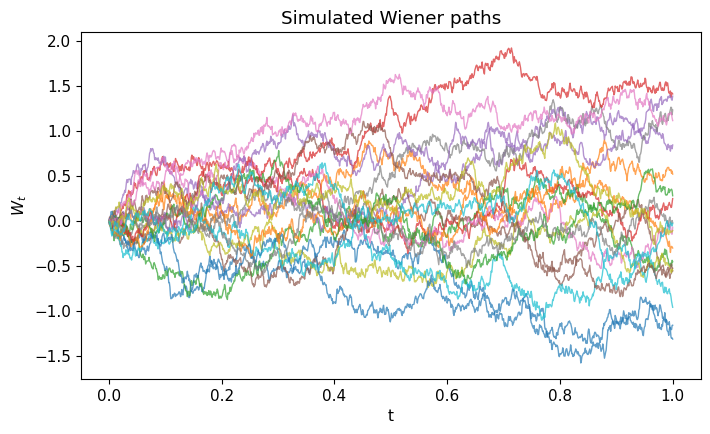

In [24]:
def brownian_motion(T=1.0, n_steps=1000, n_paths=1, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    dt = T / n_steps
    dW = np.sqrt(dt) * rng.standard_normal(size=(n_paths, n_steps))
    W = np.cumsum(dW, axis=1)
    W = np.hstack([np.zeros((n_paths, 1)), W])
    t = np.linspace(0, T, n_steps + 1)
    return t, W

t, W = brownian_motion(T=1.0, n_steps=1000, n_paths=20, rng=rng)

for i in range(W.shape[0]):
    plt.plot(t, W[i], lw=1, alpha=0.7)

plt.xlabel("t")
plt.ylabel(r"$W_t$")
plt.title("Simulated Wiener paths")
plt.show()

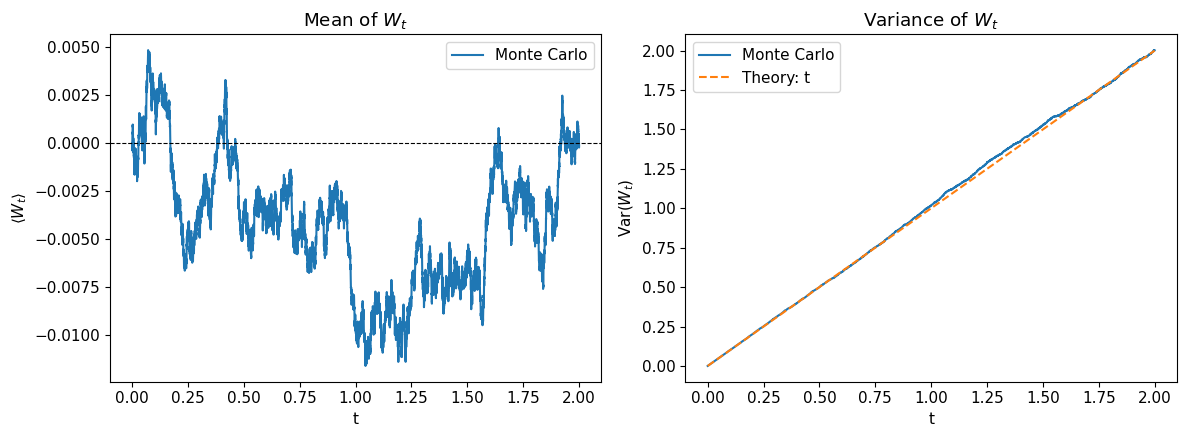

In [38]:
# Check mean and variance at different times
t, W = brownian_motion(T=2.0, n_steps=18_000, n_paths=8000, rng=rng)

mean_W = W.mean(axis=0)
var_W = W.var(axis=0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(t, mean_W, label="Monte Carlo")
ax[0].axhline(0, color="black", lw=0.8, ls="--")
ax[0].set_title(r"Mean of $W_t$")
ax[0].set_xlabel("t")
ax[0].set_ylabel(r"$\langle W_t \rangle$")

ax[1].plot(t, var_W, label="Monte Carlo")
ax[1].plot(t, t, ls="--", label="Theory: t")
ax[1].set_title(r"Variance of $W_t$")
ax[1].set_xlabel("t")
ax[1].set_ylabel(r"$\mathrm{Var}(W_t)$")

for a in ax:
    a.legend()

plt.tight_layout()
plt.show()

## 5. Itô processes, Langevin equation, and stochastic differential equations

Brownian motion models **pure noise**.  
Real systems often combine:
- a **deterministic trend** (drift),
- a **random fluctuation** (diffusion).

The standard Itô SDE is

$$
dX_t = a(X_t,t)\,dt + b(X_t,t)\,dW_t.
$$

### Interpretation
- $a(X_t,t)$: drift term,
- $b(X_t,t)$: noise amplitude,
- $\mathrm{d}W_t$: Wiener increment.

In physics, the same idea is often written in **Langevin form**:
$$
\dot X = f(X,t) + \text{noise}.
$$

A numerical method for simulating such equations is the **Euler–Maruyama method**:
$$
X_{n+1} = X_n + a(X_n,t_n)\Delta t + b(X_n,t_n)\sqrt{\Delta t}\,Z_n,
\qquad Z_n\sim\mathcal N(0,1).
$$

In [26]:
def euler_maruyama(a, b, x0, T, n_steps, n_paths=1, rng=None):
    if rng is None:
        rng = np.random.default_rng()
    dt = T / n_steps
    t = np.linspace(0, T, n_steps + 1)
    X = np.zeros((n_paths, n_steps + 1))
    X[:, 0] = x0

    for n in range(n_steps):
        tn = t[n]
        xn = X[:, n]
        dW = np.sqrt(dt) * rng.standard_normal(size=n_paths)
        X[:, n+1] = xn + a(xn, tn) * dt + b(xn, tn) * dW

    return t, X

### Example 1: Brownian motion with drift

$$
dX_t = \mu\,dt + \sigma\,dW_t.
$$

This is one of the simplest SDEs:
- drift $\mu$ pushes the mean,
- noise $\sigma$ broadens the distribution.

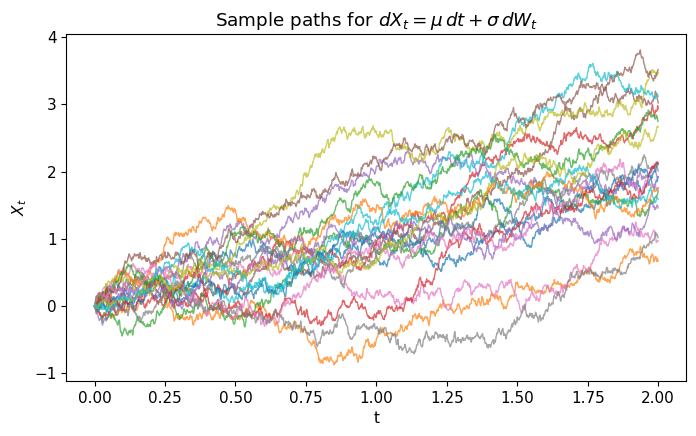

In [27]:
mu = 1.0
sigma = 0.7

a = lambda x, t: mu * np.ones_like(x)
b = lambda x, t: sigma * np.ones_like(x)

t, X = euler_maruyama(a, b, x0=0.0, T=2.0, n_steps=1200, n_paths=20, rng=rng)

for i in range(X.shape[0]):
    plt.plot(t, X[i], lw=1, alpha=0.7)

plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.title(r"Sample paths for $dX_t = \mu\,dt + \sigma\,dW_t$")
plt.show()

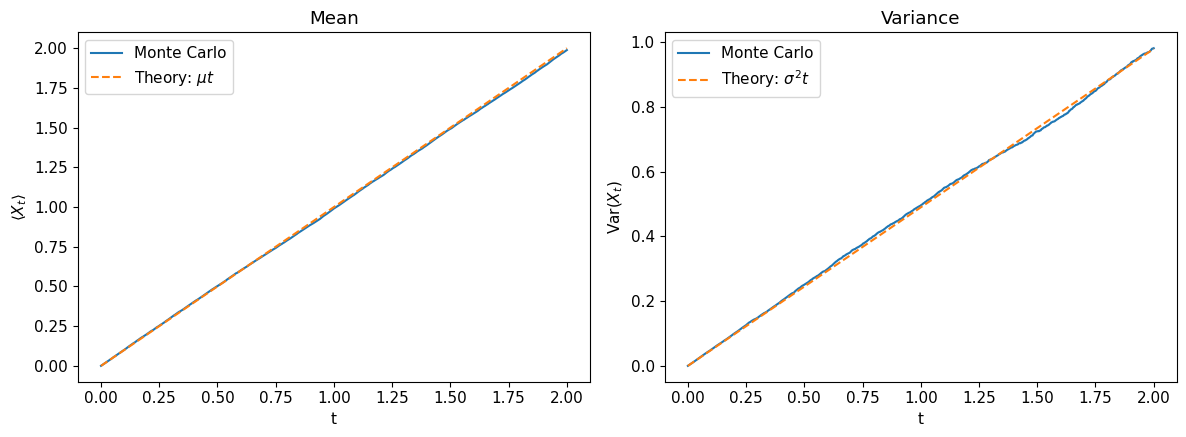

In [28]:
t, X = euler_maruyama(a, b, x0=0.0, T=2.0, n_steps=800, n_paths=8000, rng=rng)

mean_X = X.mean(axis=0)
var_X = X.var(axis=0)

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(t, mean_X, label="Monte Carlo")
ax[0].plot(t, mu * t, ls="--", label=r"Theory: $\mu t$")
ax[0].set_title("Mean")
ax[0].set_xlabel("t")
ax[0].set_ylabel(r"$\langle X_t \rangle$")

ax[1].plot(t, var_X, label="Monte Carlo")
ax[1].plot(t, sigma**2 * t, ls="--", label=r"Theory: $\sigma^2 t$")
ax[1].set_title("Variance")
ax[1].set_xlabel("t")
ax[1].set_ylabel(r"$\mathrm{Var}(X_t)$")

for a_ in ax:
    a_.legend()

plt.tight_layout()
plt.show()

### Example 2: Ornstein–Uhlenbeck process

$$
dX_t = -\gamma X_t\,dt + \sigma\,dW_t.
$$

This is a classic **mean-reverting** stochastic process:
- the drift term $-\gamma X_t$ pulls the trajectory back toward 0,
- the noise keeps it fluctuating.

This is one of the best examples for introducing both **Langevin dynamics** and the **Fokker–Planck equation** later.

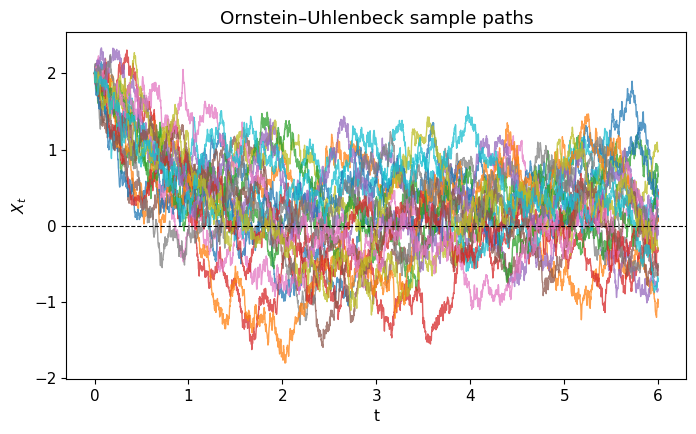

In [ ]:
gamma = 1.5
sigma = 1.0

a_ou = lambda x, t: -gamma * x
b_ou = lambda x, t: sigma * np.ones_like(x)

t, X_ou = euler_maruyama(a_ou, b_ou, x0=2.0, T=6.0, n_steps=3000, n_paths=20, rng=rng)

for i in range(X_ou.shape[0]):
    plt.plot(t, X_ou[i], lw=1, alpha=0.75)

plt.axhline(0, color="black", lw=0.8, ls="--")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.title("Ornstein–Uhlenbeck sample paths")
plt.show()

## Example 3: Cox-Ingersoll-Ross (CIR) interest-rate model:
$$
dX_t = (\alpha - \beta X_t) dt + \sigma \sqrt{X_t} dW_t 
$$
This model is a strictly positive SDE with mean reversion. This SDE has no closed form solution, but can be easily computed using our Euler-Maruyama solver.

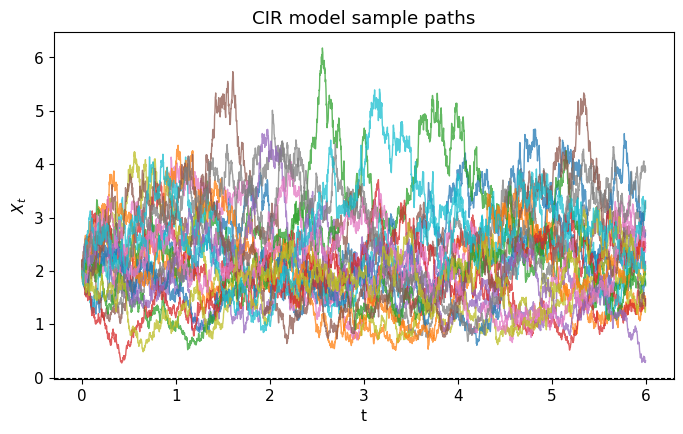

In [37]:
alpha = 3
beta = 1.5
sigma = 1.0

a_ou = lambda x, t: alpha-beta * x
b_ou = lambda x, t: sigma * np.sqrt(x)

t, X_ou = euler_maruyama(a_ou, b_ou, x0=2.0, T=6.0, n_steps=3000, n_paths=20, rng=rng)

for i in range(X_ou.shape[0]):
    plt.plot(t, X_ou[i], lw=1, alpha=0.75)

plt.axhline(0, color="black", lw=0.8, ls="--")
plt.xlabel("t")
plt.ylabel(r"$X_t$")
plt.title("CIR model sample paths")
plt.show()

## 6. Diffusion equation

Instead of asking about a single trajectory, we can ask:

> How does the **probability density** $p(x,t)$ evolve?

For pure diffusion in 1D:

$$
\frac{\partial p}{\partial t} = D \frac{\partial^2 p}{\partial x^2}.
$$

For Brownian motion written as
$$
dX_t = \sqrt{2D}\,dW_t,
$$
the density satisfies exactly the diffusion equation above.

### Fundamental solution
Starting from a point source at $x=0$, the solution is

$$
p(x,t)=\frac{1}{\sqrt{4\pi Dt}}
\exp\!\left(-\frac{x^2}{4Dt}\right).
$$

Also,
$$
\langle X_t^2 \rangle = 2Dt.
$$

So the diffusion coefficient $D$ controls how fast the cloud broadens.

In practice, a very useful habit is to look at this topic in **two ways at once**:
- simulate many particle trajectories,
- compare the resulting histogram with the density predicted by the PDE.


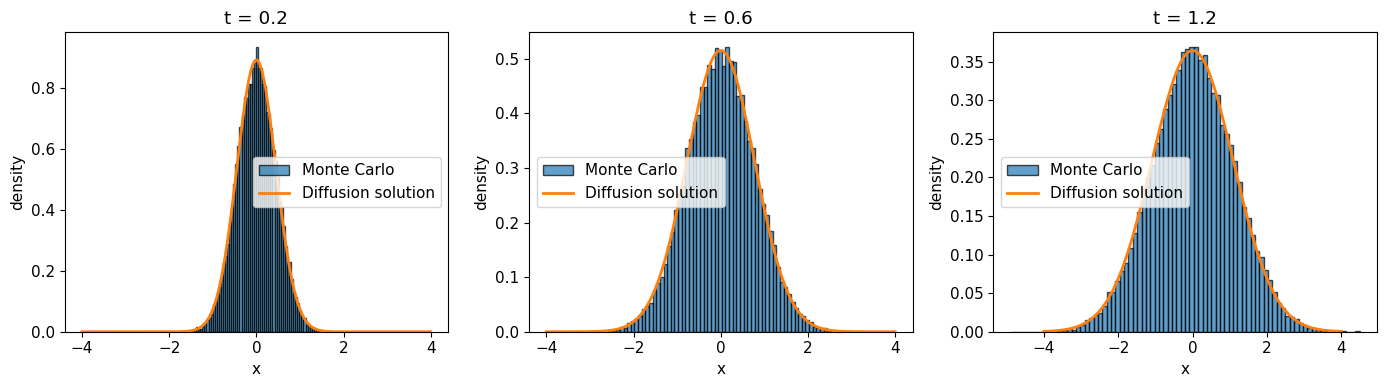

In [30]:
D = 0.5
sigma_diff = np.sqrt(2 * D)

a_diff = lambda x, t: np.zeros_like(x)
b_diff = lambda x, t: sigma_diff * np.ones_like(x)

times_to_show = [0.2, 0.6, 1.2]
T = max(times_to_show)
n_steps = 2400
n_paths = 30000

t, X_diff = euler_maruyama(a_diff, b_diff, x0=0.0, T=T, n_steps=n_steps, n_paths=n_paths, rng=rng)

indices = [np.argmin(np.abs(t - ts)) for ts in times_to_show]
x_grid = np.linspace(-4, 4, 400)

fig, ax = plt.subplots(1, len(times_to_show), figsize=(14, 4))

for j, (ts, idx) in enumerate(zip(times_to_show, indices)):
    samples = X_diff[:, idx]
    ax[j].hist(samples, bins=80, density=True, alpha=0.7, edgecolor="black", label="Monte Carlo")
    gaussian = (1 / np.sqrt(4 * np.pi * D * ts)) * np.exp(-(x_grid**2) / (4 * D * ts))
    ax[j].plot(x_grid, gaussian, lw=2, label="Diffusion solution")
    ax[j].set_title(f"t = {ts:.1f}")
    ax[j].set_xlabel("x")
    ax[j].set_ylabel("density")
    ax[j].legend()

plt.tight_layout()
plt.show()

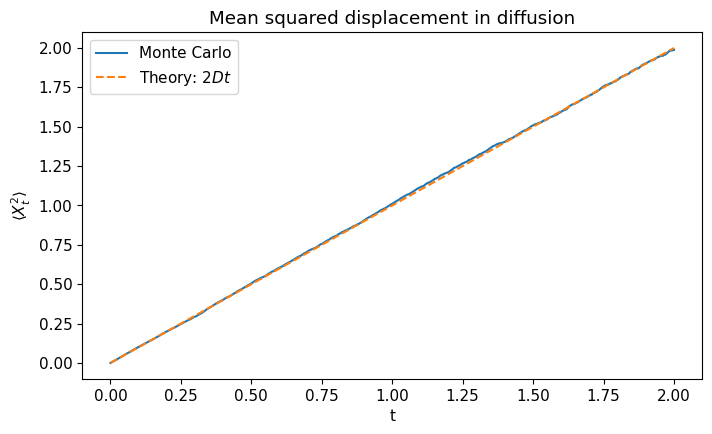

In [31]:
# Mean squared displacement for diffusion
t, X_diff = euler_maruyama(a_diff, b_diff, x0=0.0, T=2.0, n_steps=1000, n_paths=10000, rng=rng)
msd = (X_diff**2).mean(axis=0)

plt.plot(t, msd, label="Monte Carlo")
plt.plot(t, 2 * D * t, ls="--", label=r"Theory: $2Dt$")
plt.xlabel("t")
plt.ylabel(r"$\langle X_t^2\rangle$")
plt.title("Mean squared displacement in diffusion")
plt.legend()
plt.show()

### Optional numerical PDE demo: explicit finite-difference diffusion solver

This section is optional, but it is useful if you want to compare two complementary viewpoints:

- **trajectory simulation** via Monte Carlo,
- **density evolution** via a PDE solver.

Below is a simple explicit finite-difference solver for the diffusion equation.


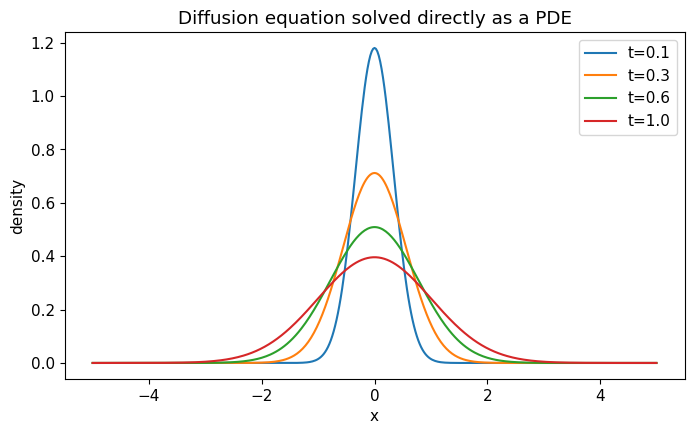

In [32]:
def solve_diffusion_fd(D=0.5, L=6.0, Nx=401, T=1.0, dt=1e-4):
    x = np.linspace(-L, L, Nx)
    dx = x[1] - x[0]
    n_steps = int(T / dt)

    # Narrow Gaussian as an approximation to a delta initial condition
    eps = 0.12
    p = np.exp(-x**2 / (2 * eps**2))
    p /= np.trapz(p, x)

    r = D * dt / dx**2
    if r > 0.5:
        print(f"Warning: explicit scheme may be unstable because D*dt/dx^2 = {r:.3f} > 0.5")

    snapshots = {}
    times = [0.1, 0.3, 0.6, 1.0]
    targets = {int(tt / dt): tt for tt in times}

    for n in range(1, n_steps + 1):
        p_new = p.copy()
        p_new[1:-1] = p[1:-1] + r * (p[2:] - 2*p[1:-1] + p[:-2])
        p_new[0] = 0.0
        p_new[-1] = 0.0
        p = p_new
        p /= np.trapz(p, x)
        if n in targets:
            snapshots[targets[n]] = p.copy()

    return x, snapshots

x_fd, snapshots = solve_diffusion_fd(D=0.5, L=5.0, Nx=401, T=1.0, dt=5e-5)

fig, ax = plt.subplots(figsize=(8, 4.5))
for tt, p in snapshots.items():
    ax.plot(x_fd, p, label=f"t={tt:.1f}")
ax.set_xlabel("x")
ax.set_ylabel("density")
ax.set_title("Diffusion equation solved directly as a PDE")
ax.legend()
plt.show()

## 7. Fokker–Planck equation

For a general 1D Itô process
$$
dX_t = a(X_t,t)\,dt + b(X_t,t)\,dW_t,
$$
the probability density $p(x,t)$ satisfies the **Fokker–Planck equation**:

$$\frac{\partial p}{\partial t}
=
-\frac{\partial}{\partial x}\big(a(x,t)p(x,t)\big)
+
\frac12 \frac{\partial^2}{\partial x^2}\big(b(x,t)^2 p(x,t)\big).
$$

### Interpretation
- the first term describes **drift / transport**,
- the second term describes **spreading due to noise**.

### Important special cases
1. **Pure diffusion**
   $$
   a=0,\qquad b=\sqrt{2D}
   $$
   gives
   $$
   \frac{\partial p}{\partial t}=D\frac{\partial^2 p}{\partial x^2}.
   $$

2. **Drift + diffusion**
   $$
   dX_t = \mu\,dt + \sigma\,dW_t
   $$
   gives
   $$
   \frac{\partial p}{\partial t}
   =
   -\mu \frac{\partial p}{\partial x}
   +
   \frac{\sigma^2}{2}\frac{\partial^2 p}{\partial x^2}.
   $$

3. **Ornstein–Uhlenbeck**
   $$
   dX_t = -\gamma X_t\,dt + \sigma\,dW_t
   $$
   gives
   $$
   \frac{\partial p}{\partial t}
   =
   \frac{\partial}{\partial x}\big(\gamma x\,p\big)
   +
   \frac{\sigma^2}{2}\frac{\partial^2 p}{\partial x^2}.
   $$

### Monte Carlo picture of the Fokker--Planck equation

The Fokker--Planck equation is the density-level version of the SDE.

A practical way to understand it is:
- simulate many trajectories from the SDE,
- build histograms,
- interpret how drift moves the cloud and diffusion broadens it.

Below we do this for the Ornstein--Uhlenbeck process.


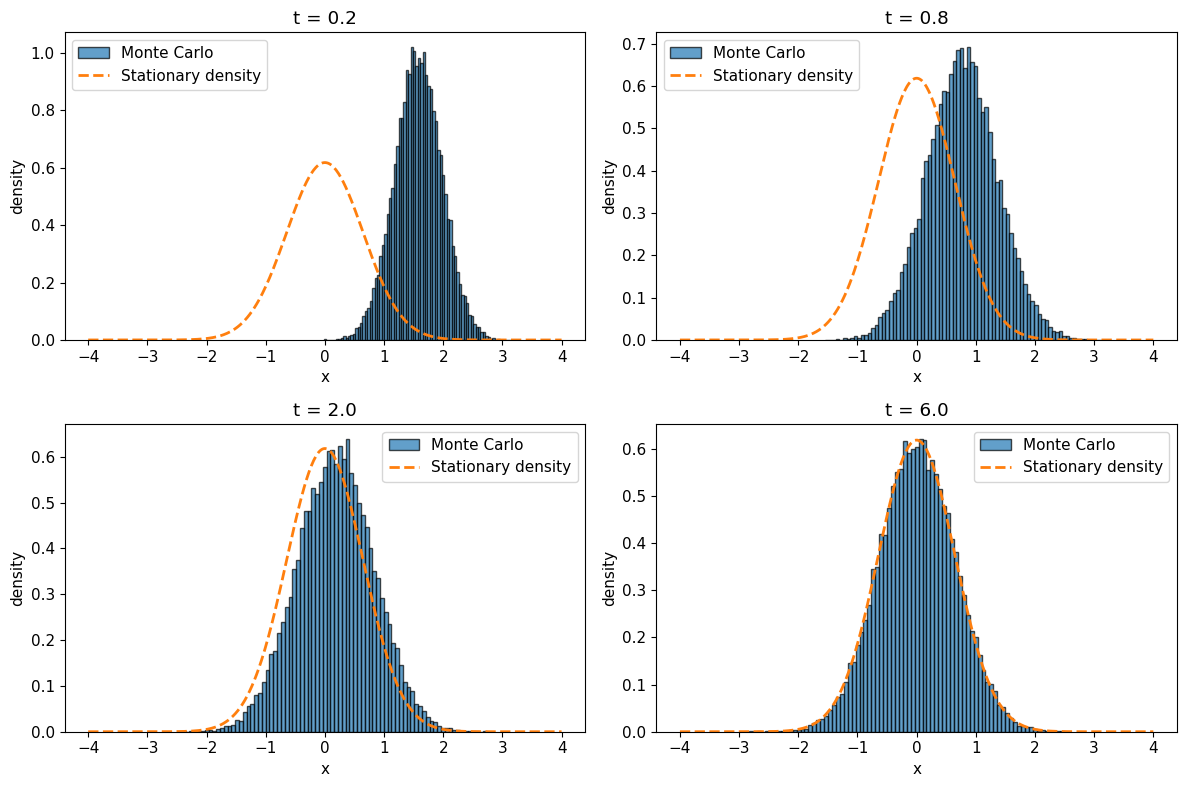

In [33]:
gamma = 1.2
sigma = 1.0

a_ou = lambda x, t: -gamma * x
b_ou = lambda x, t: sigma * np.ones_like(x)

times_to_show = [0.2, 0.8, 2.0, 6.0]
T = max(times_to_show)
n_steps = 3000
n_paths = 30000

t, X_ou = euler_maruyama(a_ou, b_ou, x0=2.0, T=T, n_steps=n_steps, n_paths=n_paths, rng=rng)
indices = [np.argmin(np.abs(t - ts)) for ts in times_to_show]
x_grid = np.linspace(-4, 4, 400)

fig, ax = plt.subplots(2, 2, figsize=(12, 8))
ax = ax.ravel()

# OU stationary density: N(0, sigma^2/(2 gamma))
var_stationary = sigma**2 / (2 * gamma)
stationary = (1 / np.sqrt(2 * np.pi * var_stationary)) * np.exp(-x_grid**2 / (2 * var_stationary))

for j, (ts, idx) in enumerate(zip(times_to_show, indices)):
    samples = X_ou[:, idx]
    ax[j].hist(samples, bins=80, density=True, alpha=0.7, edgecolor="black", label="Monte Carlo")
    ax[j].plot(x_grid, stationary, lw=2, ls="--", label="Stationary density")
    ax[j].set_title(f"t = {ts:.1f}")
    ax[j].set_xlabel("x")
    ax[j].set_ylabel("density")
    ax[j].legend()

plt.tight_layout()
plt.show()

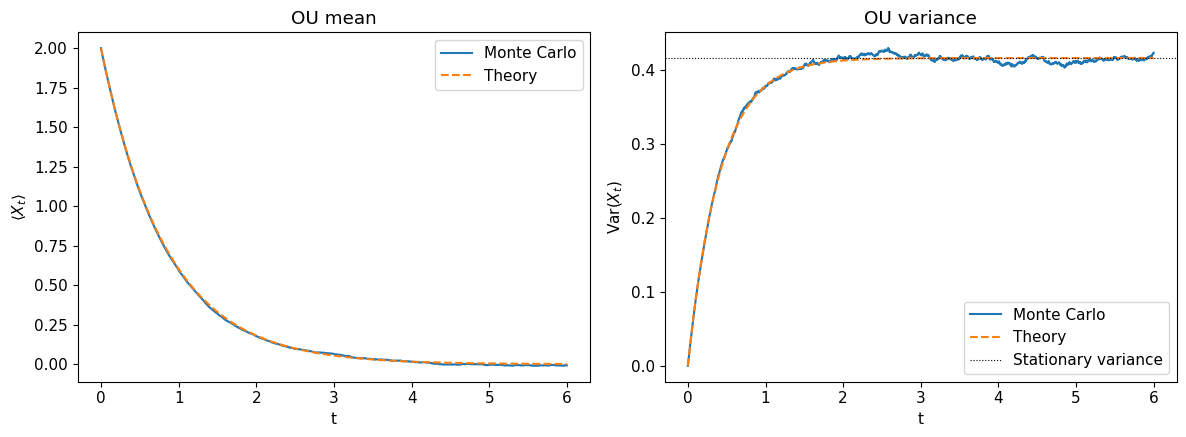

In [34]:
# Mean and variance for OU process
gamma = 1.2
sigma = 1.0
x0 = 2.0

a_ou = lambda x, t: -gamma * x
b_ou = lambda x, t: sigma * np.ones_like(x)

t, X_ou = euler_maruyama(a_ou, b_ou, x0=x0, T=6.0, n_steps=2500, n_paths=12000, rng=rng)

mean_X = X_ou.mean(axis=0)
var_X = X_ou.var(axis=0)

mean_theory = x0 * np.exp(-gamma * t)
var_theory = (sigma**2 / (2 * gamma)) * (1 - np.exp(-2 * gamma * t))

fig, ax = plt.subplots(1, 2, figsize=(12, 4.5))

ax[0].plot(t, mean_X, label="Monte Carlo")
ax[0].plot(t, mean_theory, ls="--", label="Theory")
ax[0].set_title("OU mean")
ax[0].set_xlabel("t")
ax[0].set_ylabel(r"$\langle X_t \rangle$")

ax[1].plot(t, var_X, label="Monte Carlo")
ax[1].plot(t, var_theory, ls="--", label="Theory")
ax[1].axhline(sigma**2/(2*gamma), color="black", lw=0.8, ls=":", label="Stationary variance")
ax[1].set_title("OU variance")
ax[1].set_xlabel("t")
ax[1].set_ylabel(r"$\mathrm{Var}(X_t)$")

for a_ in ax:
    a_.legend()

plt.tight_layout()
plt.show()

## 8. Compact summary

A useful summary is:

$$
\boxed{
\text{Random walk}
\to
\text{Wiener process}
\to
\text{SDE}
\to
\text{Diffusion / Fokker--Planck}
}
$$

### Two complementary viewpoints
1. **Trajectory viewpoint**
   $$
   dX_t = a(X_t,t)\,dt + b(X_t,t)\,dW_t
   $$
2. **Density viewpoint**
   $$
   \frac{\partial p}{\partial t}
   =
   -\frac{\partial}{\partial x}(ap)
   +
   \frac12 \frac{\partial^2}{\partial x^2}(b^2 p)
   $$

The Monte Carlo connection is central:
- generate many trajectories,
- estimate moments,
- approximate densities with histograms,
- compare with deterministic PDEs.


## 9. Discussion questions / exercises

1. Why does the typical displacement in a random walk scale like $\sqrt{n}$ rather than $n$?
2. Why do Wiener increments scale as $\sqrt{dt}$?
3. What is the difference between:
   - a single noisy trajectory,
   - the probability density of many realizations?
4. What role does the drift term play in an SDE?
5. How can you estimate the diffusion coefficient $D$ from Monte Carlo data?
6. What changes when the drift becomes restoring, as in the Ornstein--Uhlenbeck process?

### Optional extensions
- modify the drift and noise terms in the Euler--Maruyama solver,
- change the time step and observe numerical accuracy,
- compare free Brownian motion and Ornstein--Uhlenbeck motion side by side,
- estimate a stationary variance numerically and compare it with theory.
